In [43]:
import pandas as pd
from CosinorPy import file_parser, cosinor, cosinor1
import numpy as np

In [44]:
transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_4_tpm_normalized.csv",
    index_col=0,
)
rows_to_drop_expression_data = [
    "A2450525897_n01_undetermined",
    "A2449446903_n01_undetermined",
    "B250508004_n01_undetermined",
    "B2449500127_n01_undetermined",
]
transcriptome = transcriptome.drop(index=rows_to_drop_expression_data)
transcriptome = transcriptome.sort_index()
metadata = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_4_metadata_merged_luke_plate_5_graft.csv",
    index_col=0,
)
metadata = metadata.drop(
    columns=[
        "arb.sort",
        "sample-id",
        "Ambiguous Unstranded",
        "Ambiguous Forward",
        "Multimapping",
        "Unmapped Over Mapped",
    ]
)
metadata["Date and Time"] = metadata["date"] + " " + metadata["time"]
luke_time_data_format = "%-m/%-d/%y %-H:%-M"
metadata["Date and Time"] = pd.to_datetime(
    metadata["Date and Time"], format=luke_time_data_format
)
unusable_samples = [
    "A2450525897_n01_LICRNA01_A06",
    "A2450525897_n01_LICRNA01_A08",
    "A2450525897_n01_LICRNA01_C11",
    "A2450525897_n01_LICRNA01_D11",
    "A2450525897_n01_LICRNA01_D12",
    "A2449446903_n01_LICRNA02_F01",
    "B2449500127_n01_LICRNA04_A04",
    "B2449500127_n01_LICRNA04_A06",
    "B2449500127_n01_LICRNA04_A07",
]
borderline_unusable = [
    "A2450525897_n01_LICRNA01_F03",
    "A2450525897_n01_LICRNA01_G07",
    "A2449446903_n01_LICRNA02_A04",
    "A2449446903_n01_LICRNA02_H10",
    "B2449500127_n01_LICRNA04_H02",
    "B2449500127_n01_LICRNA04_H11",
]
all_unsable = borderline_unusable + unusable_samples
trimmed_transcriptome = transcriptome.drop(index=all_unsable)
trimmed_metadata = metadata.drop(index=all_unsable)

In [45]:
circadian_metadata = trimmed_metadata.loc[
    trimmed_metadata["Experiment Type"].str.contains("Circadian")
]
circadian_transcriptome = trimmed_transcriptome.loc[
    trimmed_metadata["Experiment Type"].str.contains("Circadian")
]

circadian_expt_2_start_time = circadian_metadata.loc[
    circadian_metadata["Experiment Type"] == "Circadian Experiment 2"
]["Date and Time"].min()
circadian_metadata["Time Since Start"] = (
    circadian_metadata["Date and Time"] - circadian_metadata["Date and Time"].iloc[0]
) / pd.Timedelta(hours=1)
circadian_metadata["Time Since Start"].loc[
    circadian_metadata["Experiment Type"] == "Circadian Experiment 2"
] = (
    circadian_metadata.loc[
        circadian_metadata["Experiment Type"] == "Circadian Experiment 2"
    ]["Date and Time"]
    - circadian_expt_2_start_time
) / pd.Timedelta(
    hours=1
)

/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_17962/3319277735.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  circadian_metadata["Time Since Start"] = (
/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_17962/3319277735.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_i

In [46]:
microbiome_abundance = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Microbiome/lic2024_16S_rab.csv"
)
circadian_microbiome = microbiome_abundance.merge(
    metadata[["sampID", "Experiment Type"]], left_on="plantID", right_on="sampID"
)
circadian_microbiome = circadian_microbiome.loc[
    circadian_microbiome["Experiment Type"] == "Circadian Experiment 1"
]

genus_sum = (
    circadian_microbiome[["Sample", "Genus", "AbundR100"]]
    .groupby(["Sample", "Genus"])
    .sum()
)
genus_sum = genus_sum.reset_index()
genus_sum_w_tp = genus_sum.merge(
    metadata[["sampID", "timepoint"]], left_on="Sample", right_on="sampID"
)
all_present_genus = genus_sum_w_tp["Genus"].unique()

## Need to fill in missing genus in every sample first
for sampID in genus_sum_w_tp["sampID"].unique():
    sampid_only_df = genus_sum_w_tp.loc[genus_sum_w_tp["sampID"] == sampID]
    present_genus_in_samp = sampid_only_df["Genus"].unique()
    difference_in_present_bacteria = list(
        set(all_present_genus) - set(present_genus_in_samp)
    )
    current_time_point = sampid_only_df["timepoint"].iloc[0]
    empty_df_to_add = pd.DataFrame(
        columns=["Sample", "Genus", "AbundR100", "sampID", "timepoint"]
    )
    empty_df_to_add["Genus"] = difference_in_present_bacteria
    empty_df_to_add["Sample"] = sampID
    empty_df_to_add["AbundR100"] = 0
    empty_df_to_add["sampID"] = sampID
    empty_df_to_add["timepoint"] = current_time_point
    genus_sum_w_tp = pd.concat([genus_sum_w_tp, empty_df_to_add])


timepoint_average_abundance = (
    genus_sum_w_tp[["Genus", "timepoint", "AbundR100"]]
    .groupby(["Genus", "timepoint"])
    .mean()
)
timepoint_average_abundance = timepoint_average_abundance.reset_index()
timepoint_cleaned_average_abundance = timepoint_average_abundance.copy()
for genus in timepoint_cleaned_average_abundance["Genus"].unique():
    genus_df = timepoint_cleaned_average_abundance.loc[
        timepoint_cleaned_average_abundance["Genus"] == genus
    ]
    if sum(genus_df["AbundR100"] > 0) < 8:
        timepoint_cleaned_average_abundance = timepoint_cleaned_average_abundance.loc[
            timepoint_cleaned_average_abundance["Genus"] != genus
        ]

In [47]:
print(timepoint_cleaned_average_abundance["Genus"].unique())

['Actinomycetospora' 'Actinoplanes' 'Aeromicrobium' 'Aetherobacter'
 'Agrobacterium' 'Aureimonas_A_501549' 'Blastococcus' 'Brevundimonas'
 'Caldora' 'Chryseobacterium_A_796612' 'Flavobacterium' 'Friedmanniella'
 'Frigoribacterium' 'Herbaspirillum' 'Hylemonella'
 'Janthinobacterium_571130' 'Janthinobacterium_571526' 'Kineococcus'
 'Kineosporia' 'Klenkia' 'Kordiimonas' 'Massilia_573596' 'Massilia_574424'
 'Massilia_574544' 'Methylobacterium' 'Microbacterium_A_383321'
 'Mycobacterium' 'Nakamurella' 'Neorhizobium_500197'
 'Nocardioides_A_392796' 'Paucimonas' 'Pigmentiphaga'
 'Pseudoduganella_570666' 'Pseudomonas_E_647464' 'Ramlibacter_588642'
 'Rathayibacter' 'Rhodoferax_C' 'Rugamonas_570800' 'Sphingomonas_L_486704'
 'Telluria_573210' 'Variovorax']


In [48]:
timepoint_cleaned_average_abundance = timepoint_cleaned_average_abundance.merge(
    circadian_metadata[["timepoint", "Time Since Start"]],
    left_on="timepoint",
    right_on="timepoint",
)

In [49]:
timepoint_cleaned_average_abundance

,Genus,timepoint,AbundR100,Time Since Start
0,Actinomycetospora,c1_t01,0.375,0.0
1,Actinomycetospora,c1_t01,0.375,0.0
2,Actinomycetospora,c1_t01,0.375,0.0
3,Actinomycetospora,c1_t01,0.375,0.0
4,Actinomycetospora,c1_t01,0.375,0.0
...,...,...,...,...
4464,Variovorax,c1_t13,3.775,48.0
4465,Variovorax,c1_t13,3.775,48.0
4466,Variovorax,c1_t13,3.775,48.0
4467,Variovorax,c1_t13,3.775,48.0


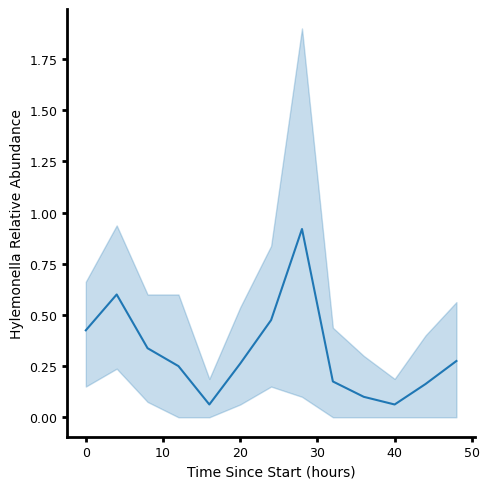

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

experiment_1_timepoints = (
    circadian_metadata.loc[
        circadian_metadata["Experiment Type"] == "Circadian Experiment 1",
        ["timepoint", "Time Since Start"],
    ]
    .drop_duplicates(subset=["timepoint"])
    .sort_values("Time Since Start")
)

hylemonella_plot_data = (
    genus_sum_w_tp.loc[
        genus_sum_w_tp["Genus"] == "Hylemonella",
        ["Sample", "timepoint", "AbundR100"],
    ]
    .merge(experiment_1_timepoints, on="timepoint", how="left")
    .rename(columns={"AbundR100": "Hylemonella"})
    .sort_values("Time Since Start")
)

fig, ax = plt.subplots(figsize=(5, 5), dpi=100)
fig.patch.set_facecolor("white")
sns.lineplot(
    data=hylemonella_plot_data,
    x="Time Since Start",
    y="Hylemonella",
    errorbar=("ci", 95),
    err_style="band",
    err_kws={"alpha": 0.25},
    color="#1f77b4",
    ax=ax,
    sort=True,
    estimator="mean",
)
plt.ylabel("Hylemonella Relative Abundance", fontsize=10)
plt.xlabel("Time Since Start (hours)", fontsize=10)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.spines["top"].set_color("black")
ax.spines["top"].set_linewidth(0)
ax.tick_params(axis="both", width=2)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [51]:
timepoint_formatted_for_cosinor = timepoint_cleaned_average_abundance.rename(
    columns={"Time Since Start": "x", "AbundR100": "y", "Genus": "test"}
)
timepoint_formatted_for_cosinor = timepoint_formatted_for_cosinor[["test", "x", "y"]]
timepoint_formatted_for_cosinor

,test,x,y
0,Actinomycetospora,0.0,0.375
1,Actinomycetospora,0.0,0.375
2,Actinomycetospora,0.0,0.375
3,Actinomycetospora,0.0,0.375
4,Actinomycetospora,0.0,0.375
...,...,...,...
4464,Variovorax,48.0,3.775
4465,Variovorax,48.0,3.775
4466,Variovorax,48.0,3.775
4467,Variovorax,48.0,3.775


In [52]:
timepoint_formatted_for_cosinor.to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/Circadian_experiment_1_microbiome_cosinor_plotting_data.csv",
    index=False,
)

In [53]:
# cosinor_results = cosinor1.fit_group(timepoint_formatted_for_cosinor, period=[24])

cosinor_results = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/Circadian_experiment_1_microbiome_cosinor_results.csv"
)

In [54]:
# cosinor_results.to_csv(
#     "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/Circadian_experiment_1_microbiome_cosinor_results.csv",
#     index=False,
# )

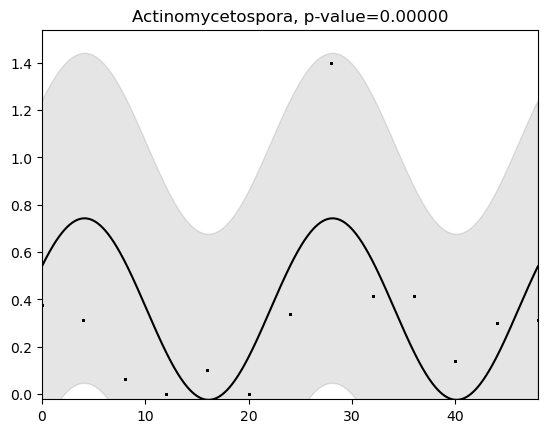

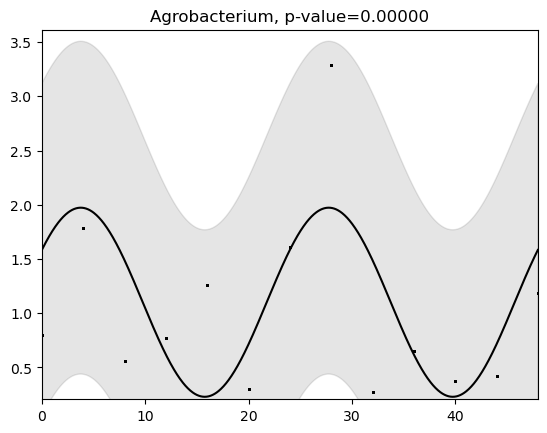

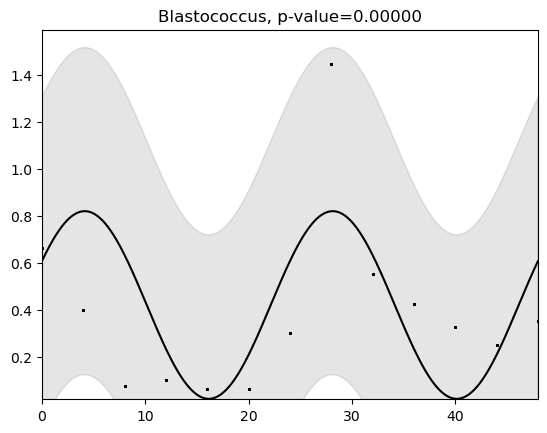

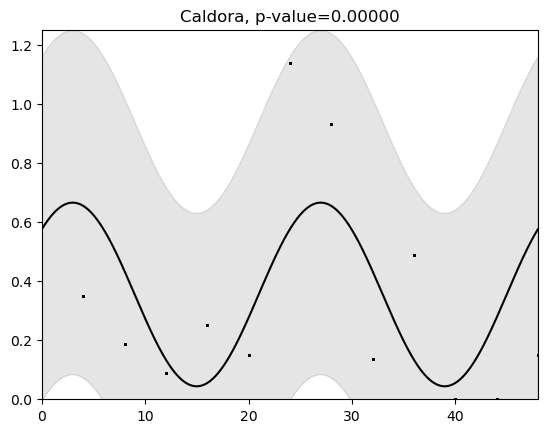

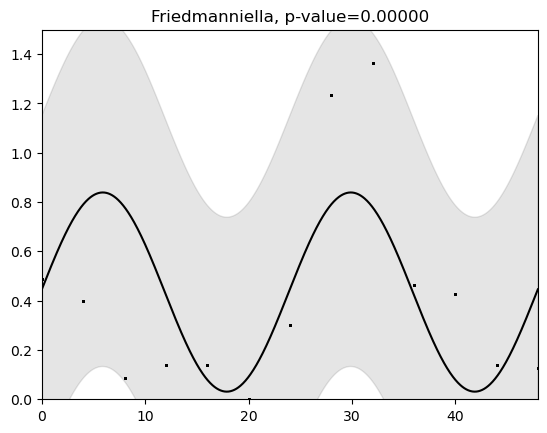

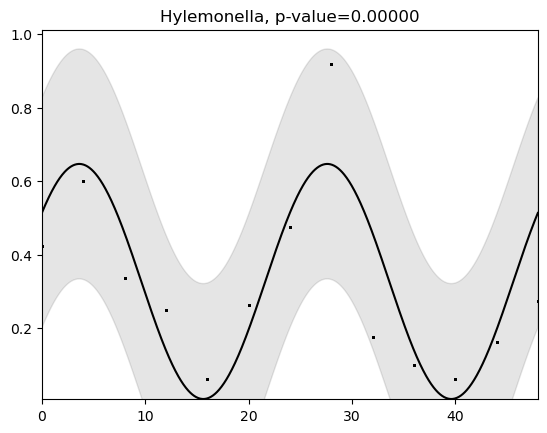

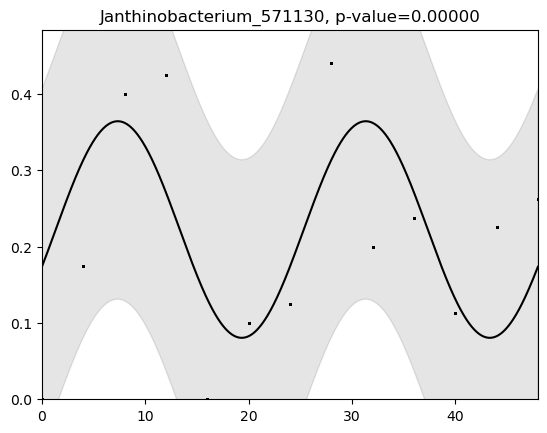

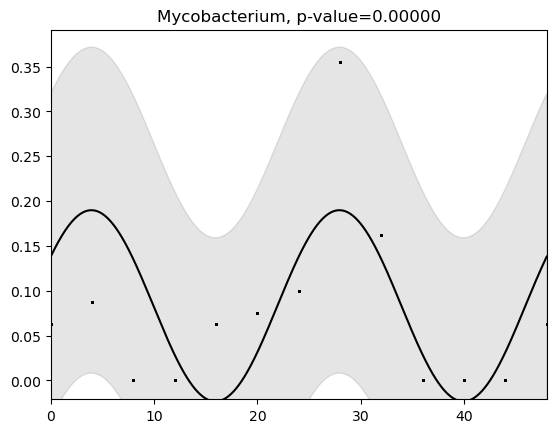

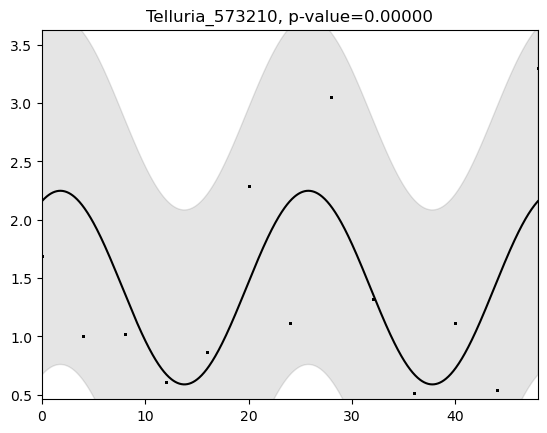

In [55]:
significant_tests = cosinor_results.loc[cosinor_results["p"] < 1e-10, "test"]
timepoint_formatted_for_cosinor_sig = timepoint_formatted_for_cosinor.loc[
    timepoint_formatted_for_cosinor["test"].isin(significant_tests)
].copy()
cosinor_results_sig_only = cosinor1.fit_group(
    timepoint_formatted_for_cosinor_sig, period=[24]
)

In [56]:
circadian_microbiome = microbiome_abundance.merge(
    metadata[["sampID", "Experiment Type"]], left_on="plantID", right_on="sampID"
)
circadian_microbiome_2 = circadian_microbiome.loc[
    circadian_microbiome["Experiment Type"] == "Circadian Experiment 2"
]

genus_sum_2 = (
    circadian_microbiome_2[["Sample", "Genus", "AbundR100"]]
    .groupby(["Sample", "Genus"])
    .sum()
)
genus_sum_2 = genus_sum_2.reset_index()
genus_sum_w_tp_2 = genus_sum_2.merge(
    metadata[["sampID", "timepoint"]], left_on="Sample", right_on="sampID"
)
all_present_genus_2 = genus_sum_w_tp_2["Genus"].unique()

## Need to fill in missing genus in every sample first
for sampID in genus_sum_w_tp_2["sampID"].unique():
    sampid_only_df_2 = genus_sum_w_tp_2.loc[genus_sum_w_tp_2["sampID"] == sampID]
    present_genus_in_samp_2 = sampid_only_df_2["Genus"].unique()
    difference_in_present_bacteria_2 = list(
        set(all_present_genus_2) - set(present_genus_in_samp_2)
    )
    current_time_point_2 = sampid_only_df_2["timepoint"].iloc[0]
    empty_df_to_add_2 = pd.DataFrame(
        columns=["Sample", "Genus", "AbundR100", "sampID", "timepoint"]
    )
    empty_df_to_add_2["Genus"] = difference_in_present_bacteria_2
    empty_df_to_add_2["Sample"] = sampID
    empty_df_to_add_2["AbundR100"] = 0
    empty_df_to_add_2["sampID"] = sampID
    empty_df_to_add_2["timepoint"] = current_time_point_2
    genus_sum_w_tp_2 = pd.concat([genus_sum_w_tp_2, empty_df_to_add_2])


timepoint_average_abundance_2 = (
    genus_sum_w_tp_2[["Genus", "timepoint", "AbundR100"]]
    .groupby(["Genus", "timepoint"])
    .mean()
)
timepoint_average_abundance_2 = timepoint_average_abundance_2.reset_index()
timepoint_cleaned_average_abundance_2 = timepoint_average_abundance_2.copy()
for genus in timepoint_cleaned_average_abundance_2["Genus"].unique():
    genus_df = timepoint_cleaned_average_abundance_2.loc[
        timepoint_cleaned_average_abundance_2["Genus"] == genus
    ]
    if sum(genus_df["AbundR100"] > 0) < 8:
        timepoint_cleaned_average_abundance_2 = (
            timepoint_cleaned_average_abundance_2.loc[
                timepoint_cleaned_average_abundance_2["Genus"] != genus
            ]
        )
timepoint_cleaned_average_abundance_2 = timepoint_cleaned_average_abundance_2.merge(
    circadian_metadata[["timepoint", "Time Since Start"]],
    left_on="timepoint",
    right_on="timepoint",
)

In [57]:
timepoint_formatted_for_cosinor_2 = timepoint_cleaned_average_abundance_2.rename(
    columns={"Time Since Start": "x", "AbundR100": "y", "Genus": "test"}
)
timepoint_formatted_for_cosinor_2 = timepoint_formatted_for_cosinor_2[
    ["test", "x", "y"]
]
timepoint_formatted_for_cosinor_2

,test,x,y
0,Actinomycetospora,0.0,0.216667
1,Actinomycetospora,0.0,0.216667
2,Actinomycetospora,0.0,0.216667
3,Actinomycetospora,0.0,0.216667
4,Actinomycetospora,0.0,0.216667
...,...,...,...
4177,Variovorax,48.0,3.587500
4178,Variovorax,48.0,3.587500
4179,Variovorax,48.0,3.587500
4180,Variovorax,48.0,3.587500


In [58]:
# timepoint_formatted_for_cosinor_2.to_csv(
#     "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/Circadian_experiment_2_microbiome_cosinor_plotting_data.csv",
#     index=False,
# )

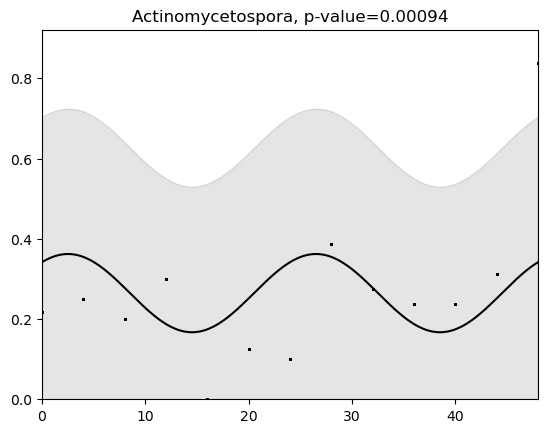

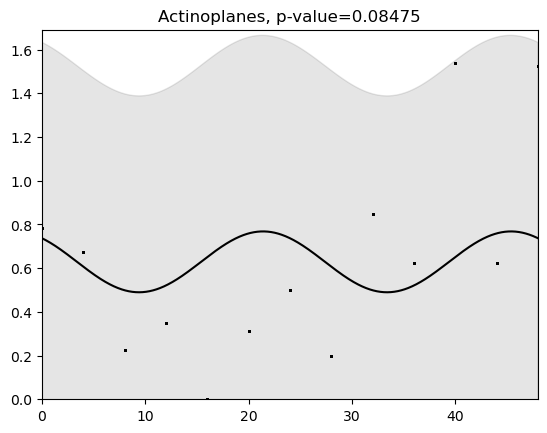

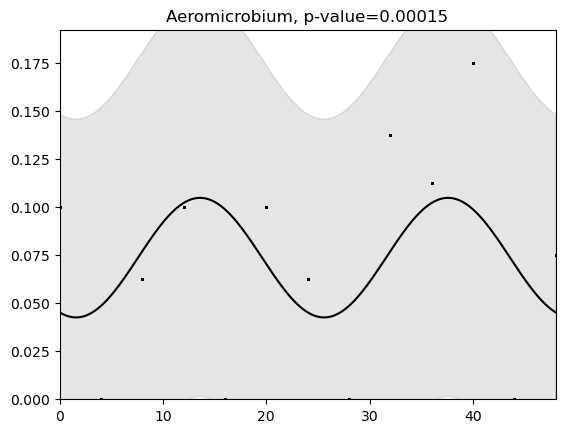

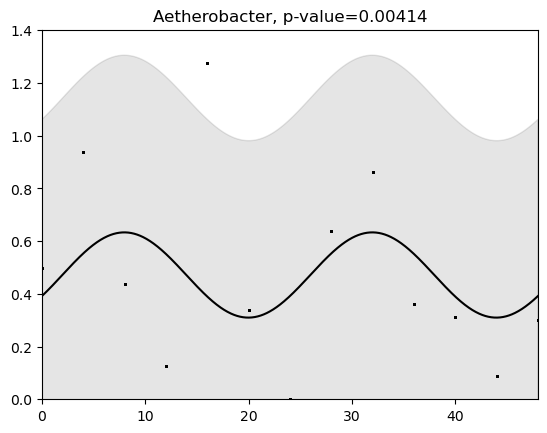

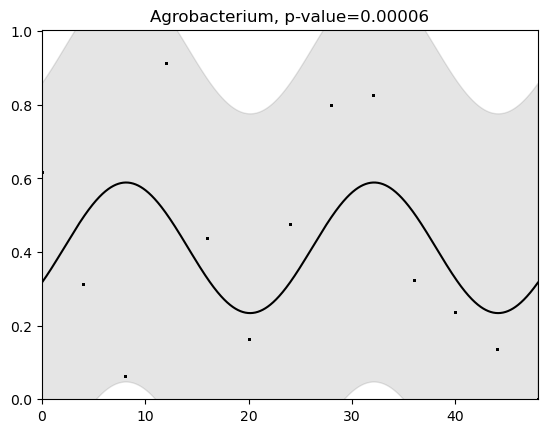

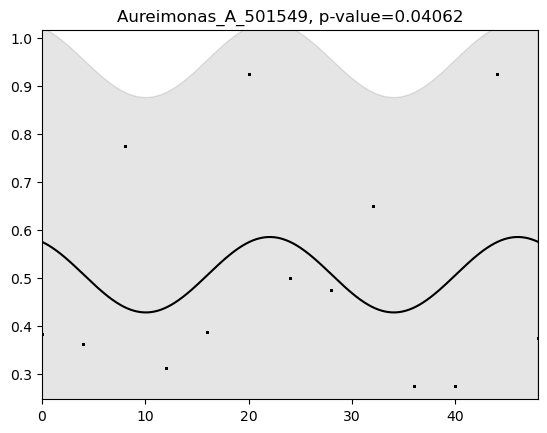

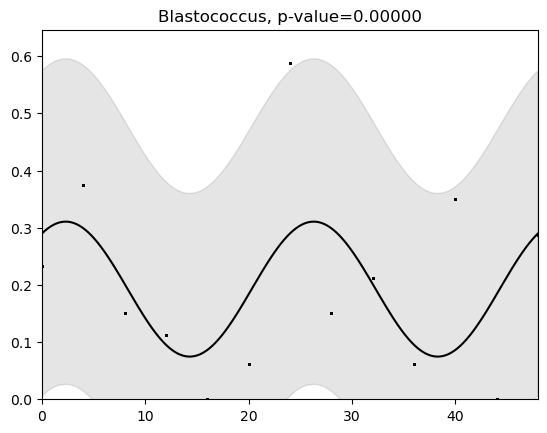

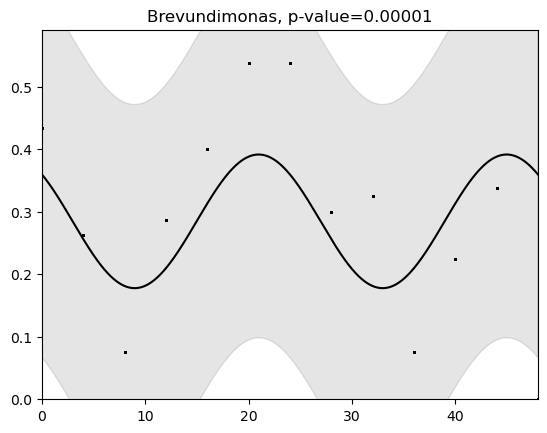

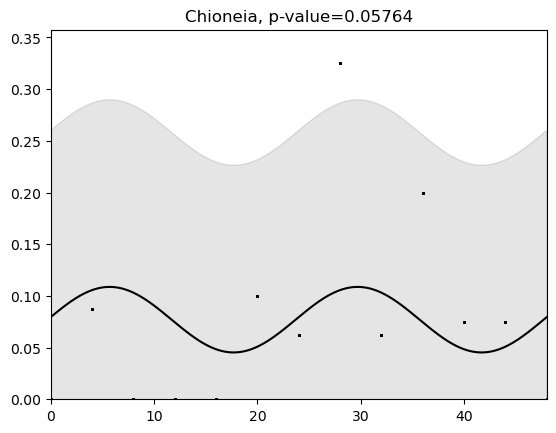

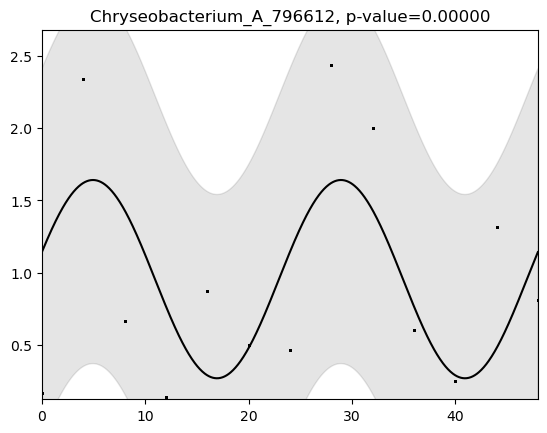

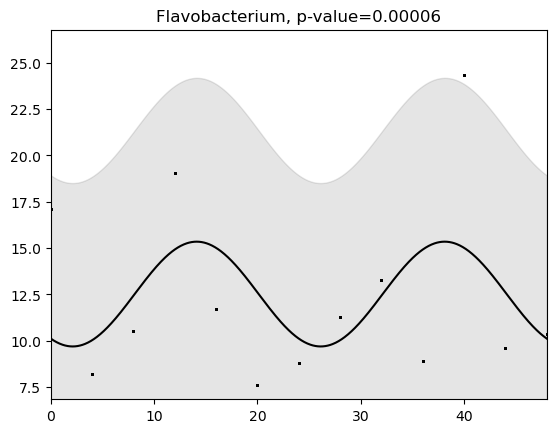

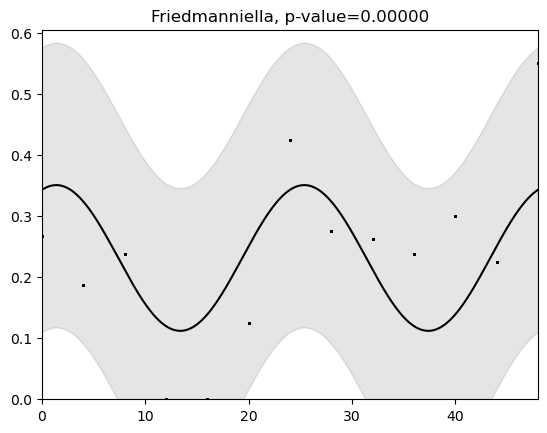

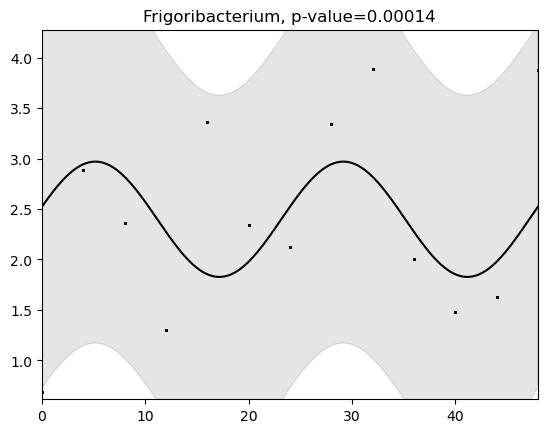

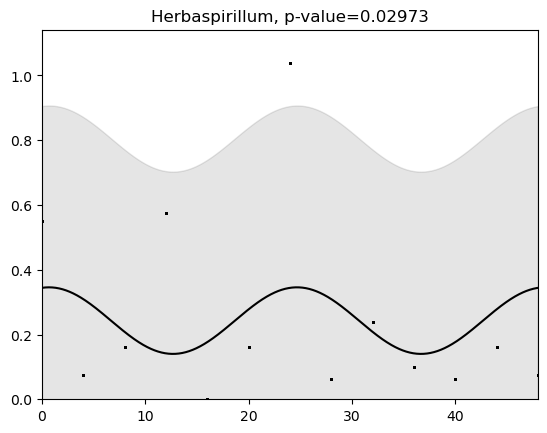

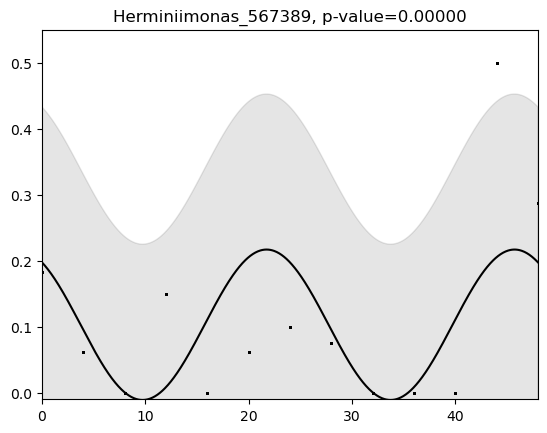

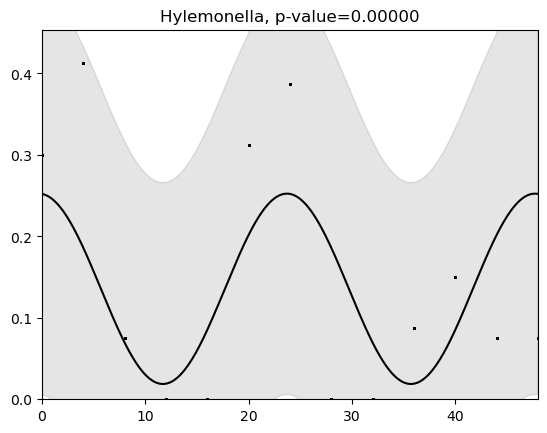

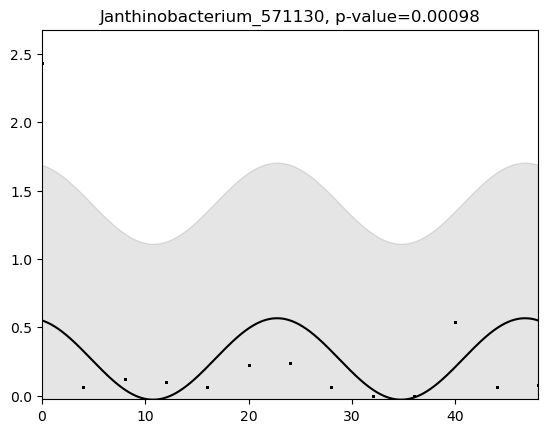

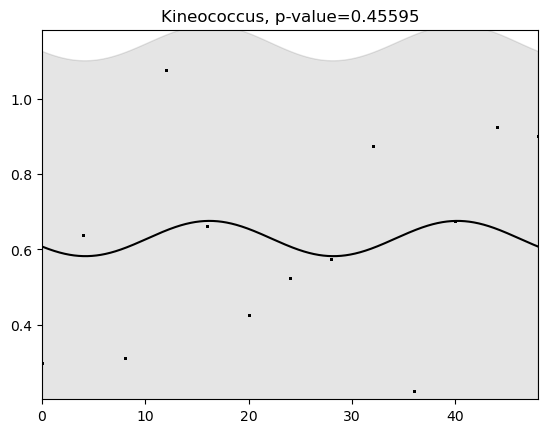

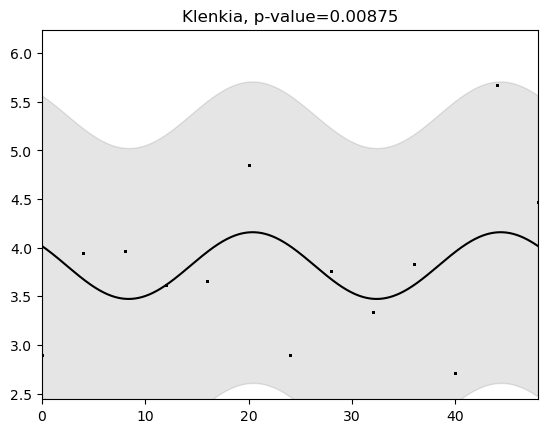

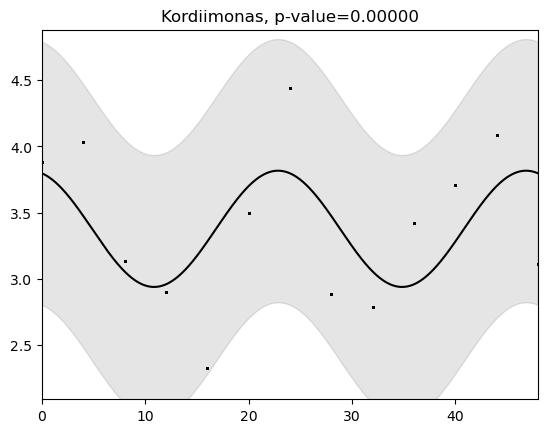

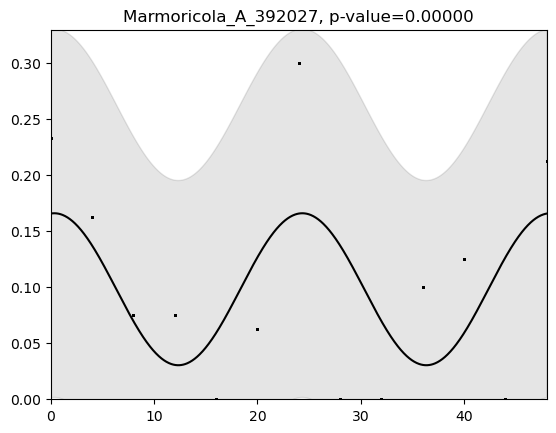

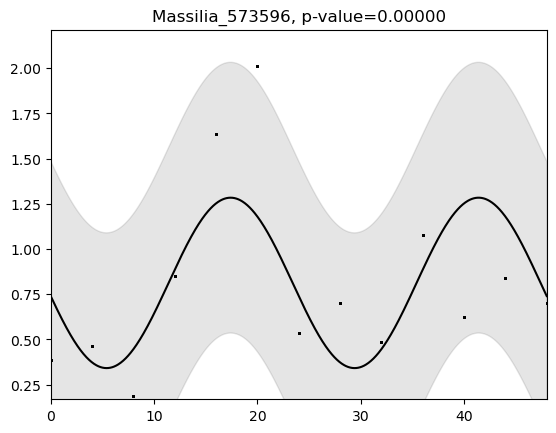

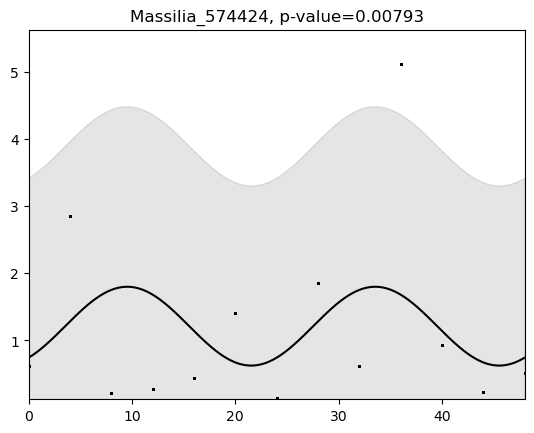

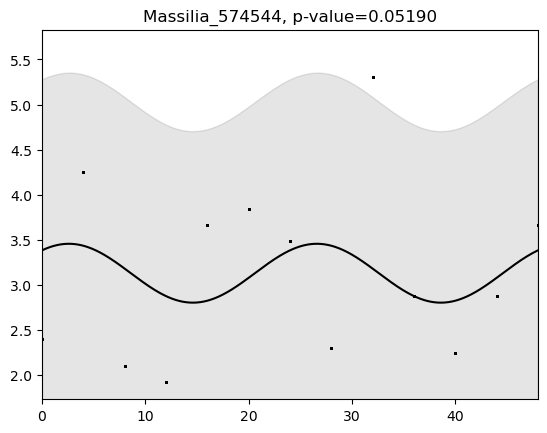

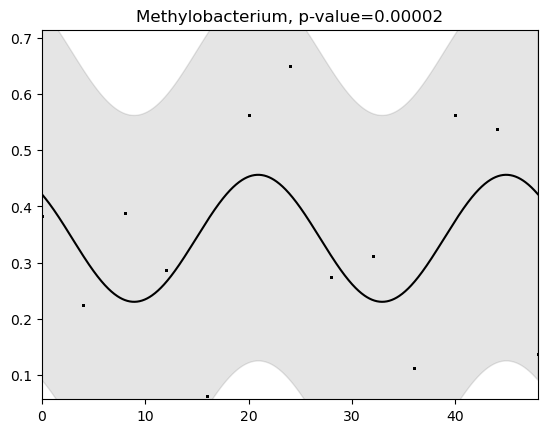

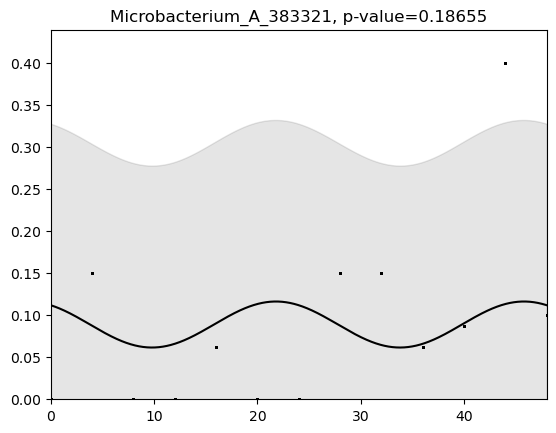

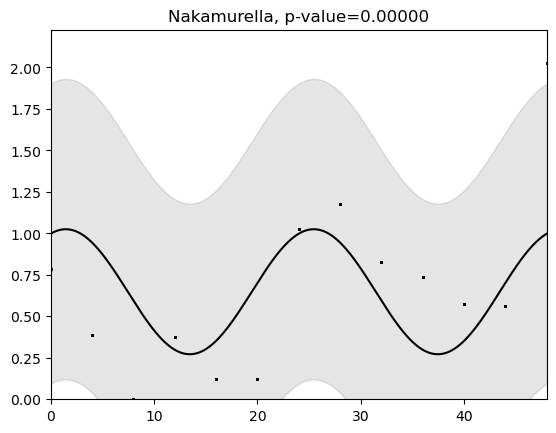

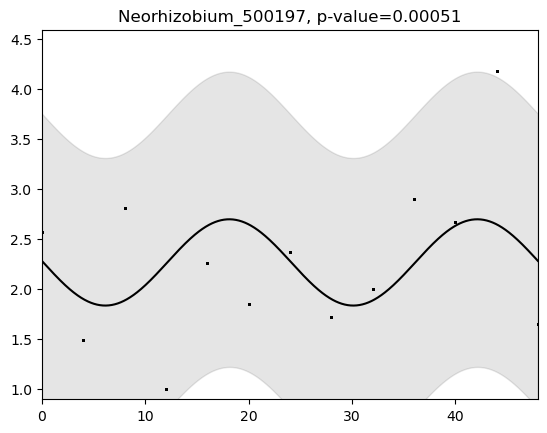

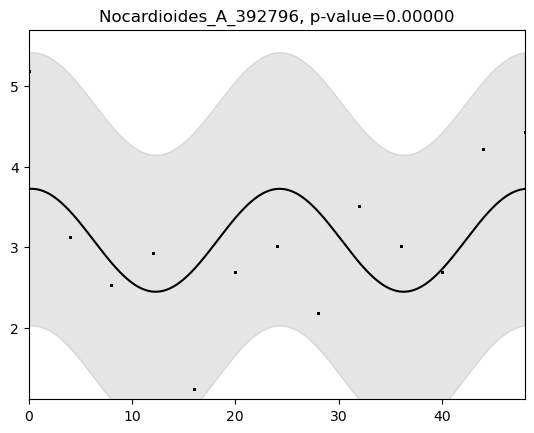

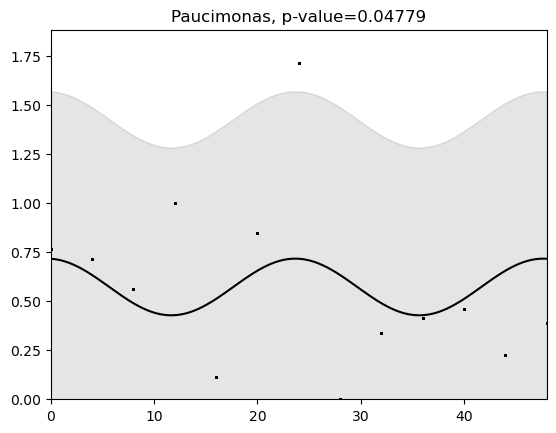

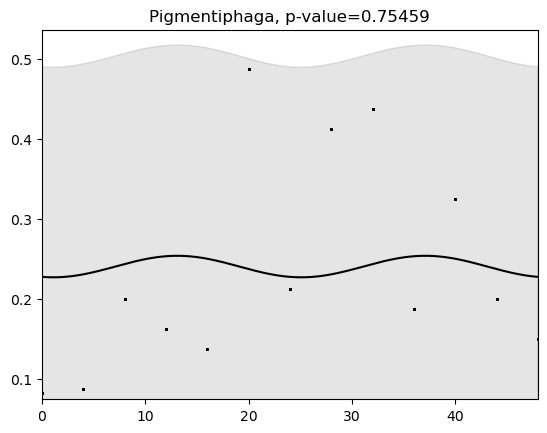

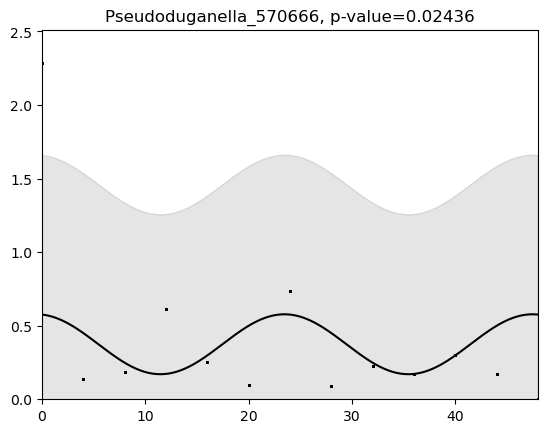

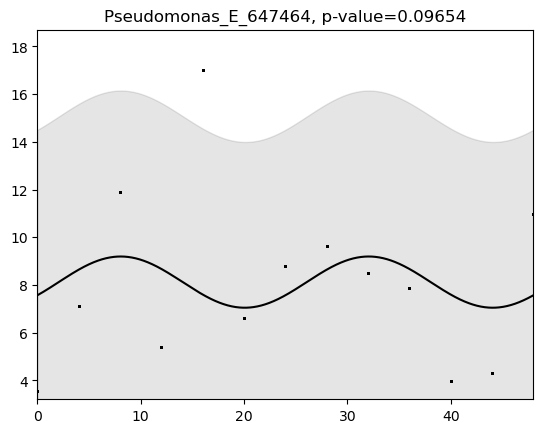

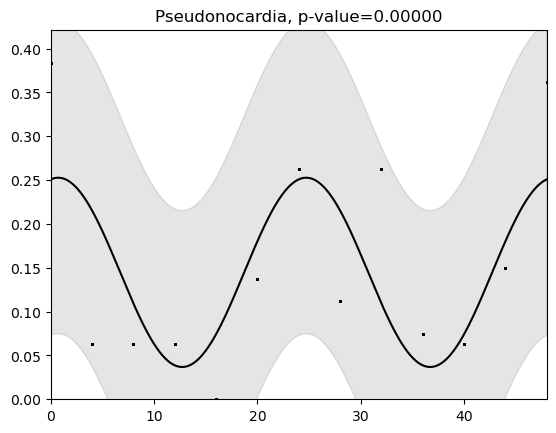

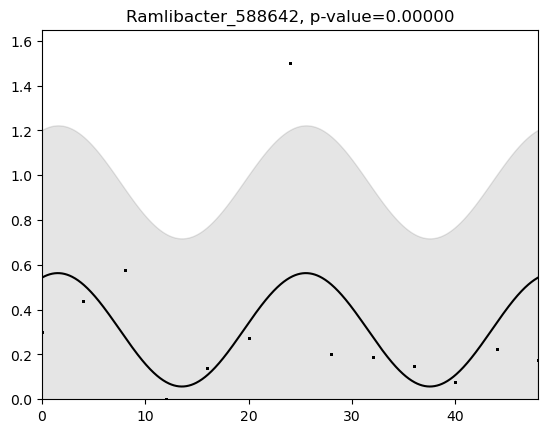

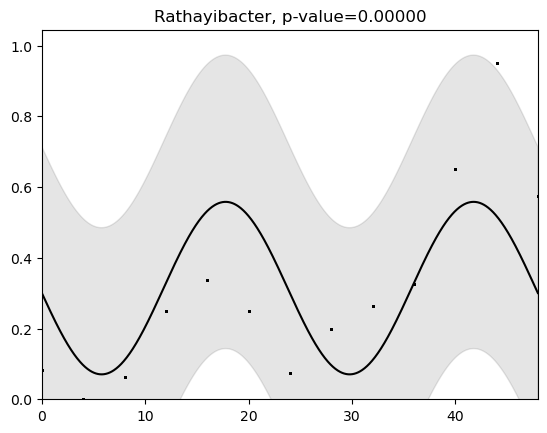

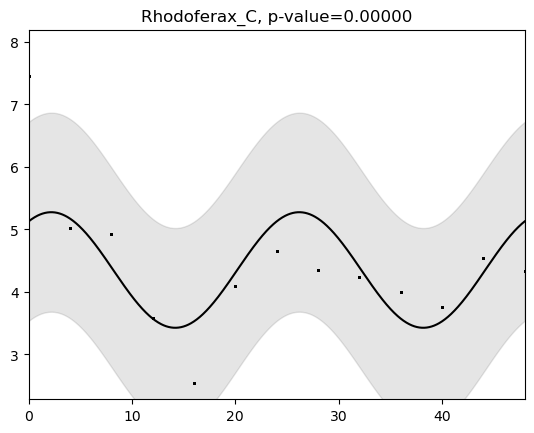

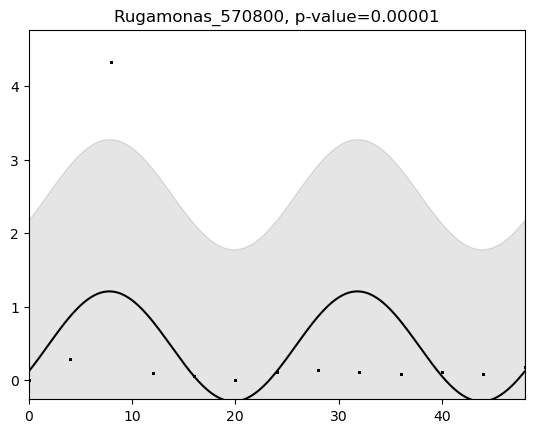

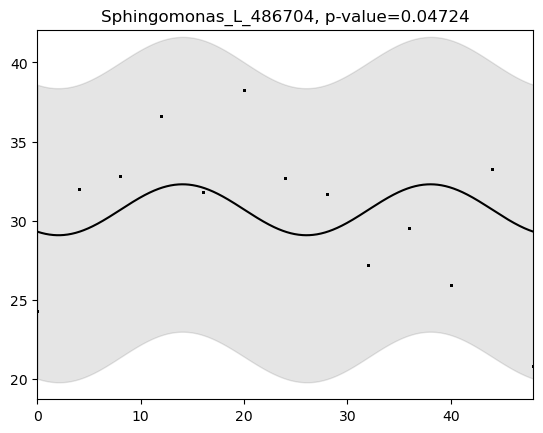

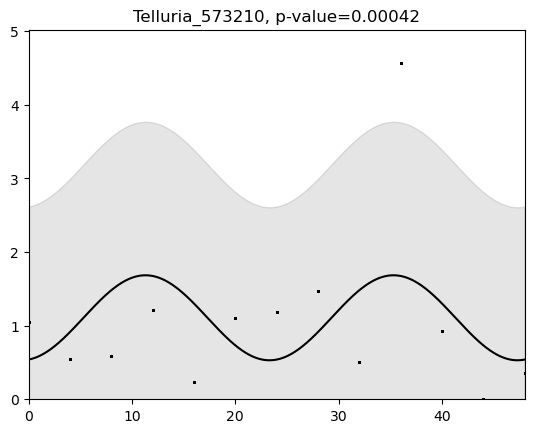

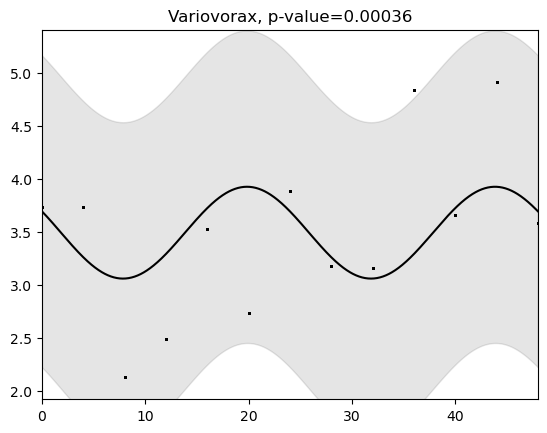

In [59]:
cosinor_results_2 = cosinor1.fit_group(timepoint_formatted_for_cosinor_2, period=[24])

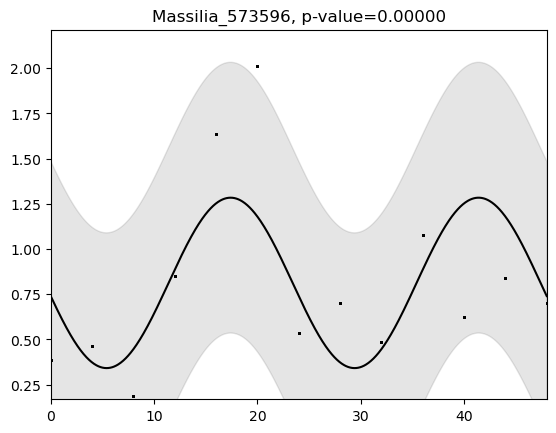

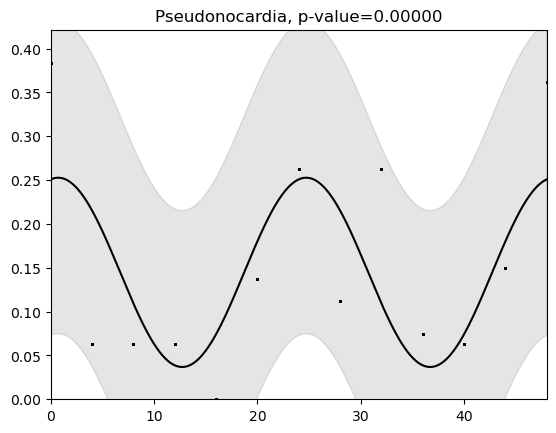

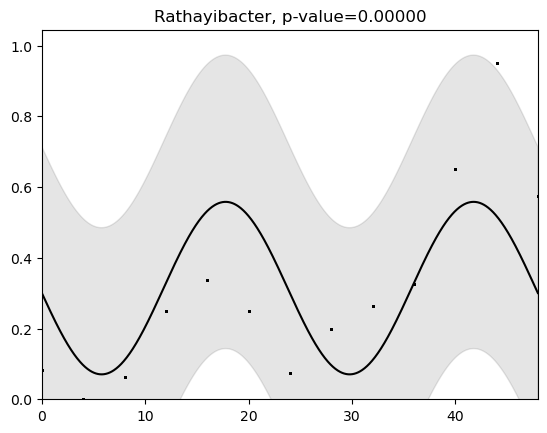

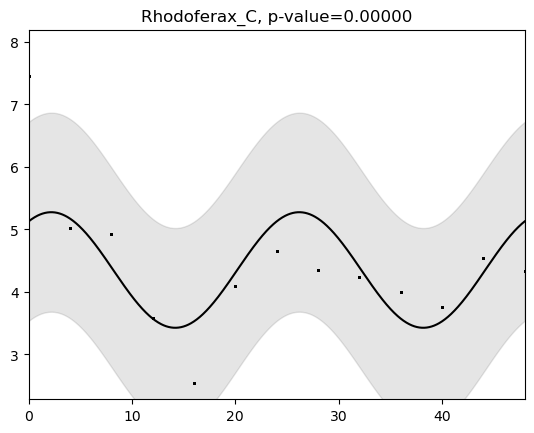

In [60]:
significant_tests_2 = cosinor_results_2.loc[cosinor_results_2["p"] < 1e-10, "test"]
timepoint_formatted_for_cosinor_sig_2 = timepoint_formatted_for_cosinor_2.loc[
    timepoint_formatted_for_cosinor_2["test"].isin(significant_tests_2)
].copy()
cosinor_results_sig_only_2 = cosinor1.fit_group(
    timepoint_formatted_for_cosinor_sig_2, period=[24]
)

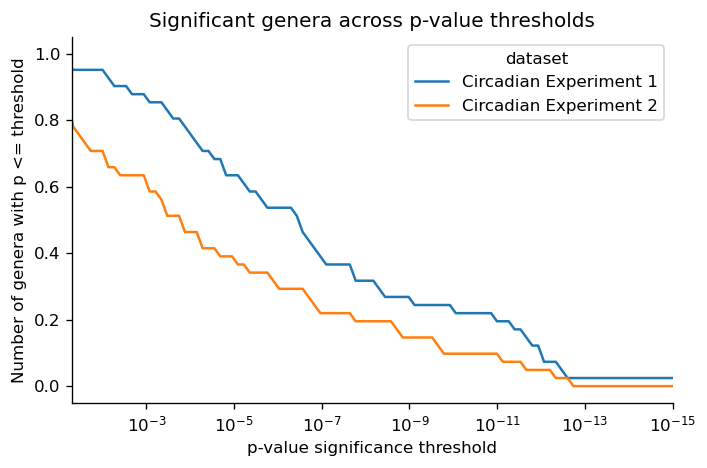

In [61]:
plot_results = pd.concat(
    [
        cosinor_results[["p"]].assign(dataset="Circadian Experiment 1"),
        cosinor_results_2[["p"]].assign(dataset="Circadian Experiment 2"),
    ],
    ignore_index=True,
)

positive_p = plot_results.loc[plot_results["p"] > 0, "p"]
if positive_p.empty:
    raise ValueError("No positive p-values were found to build the threshold plot.")

thresholds = np.logspace(
    np.log10(positive_p.min()),
    np.log10(plot_results["p"].max()),
    200,
)

threshold_count_frames = []
for dataset_name, dataset_df in plot_results.groupby("dataset"):
    valid_p = dataset_df["p"].dropna()
    total_genera = len(valid_p)
    threshold_count_frames.append(
        pd.DataFrame(
            {
                "dataset": dataset_name,
                "p_threshold": thresholds,
                "significant_count": [
                    (valid_p <= threshold).sum() for threshold in thresholds
                ],
                "total_genera": total_genera,
                "significant_fraction": [
                    (valid_p <= threshold).sum() / total_genera
                    for threshold in thresholds
                ],
            }
        )
    )

threshold_counts = pd.concat(threshold_count_frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
sns.lineplot(
    data=threshold_counts,
    x="p_threshold",
    y="significant_fraction",
    hue="dataset",
    ax=ax,
)
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_xlim(5e-2, 1e-15)
ax.set_xlabel("p-value significance threshold")
ax.set_ylabel("Number of genera with p <= threshold")
ax.set_title("Significant genera across p-value thresholds")
sns.despine()
plt.tight_layout()
plt.show()

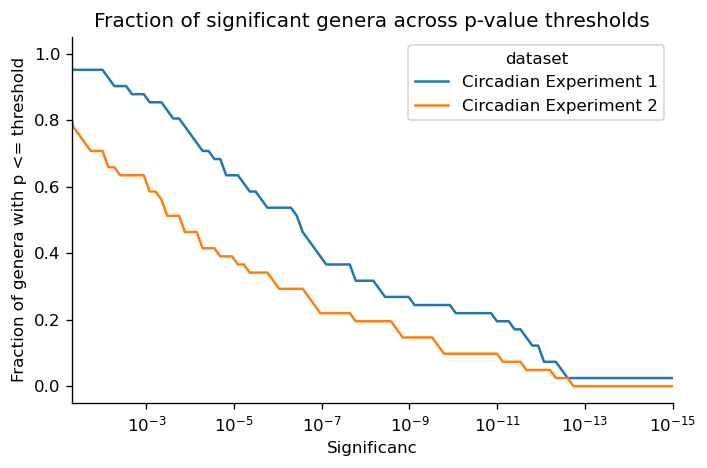

In [62]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
sns.lineplot(
    data=threshold_counts,
    x="p_threshold",
    y="significant_fraction",
    hue="dataset",
    ax=ax,
)
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_xlim(5e-2, 1e-15)
ax.set_xlabel("Significanc")
ax.set_ylabel("Fraction of genera with p <= threshold")
ax.set_title("Fraction of significant genera across p-value thresholds")
sns.despine()
plt.tight_layout()
plt.show()

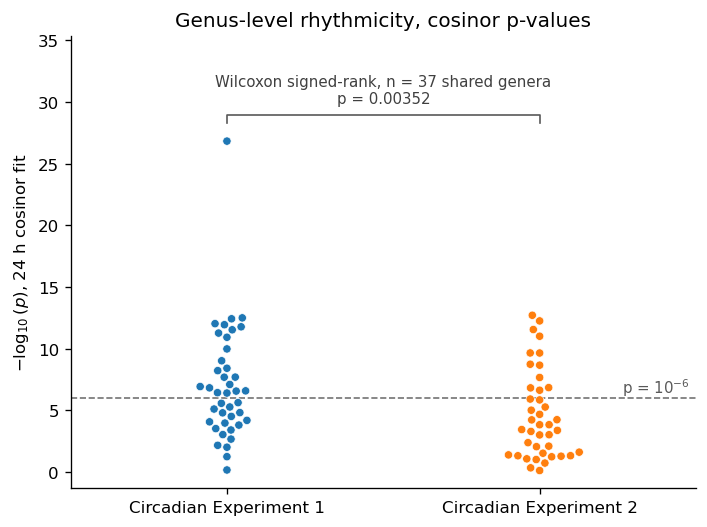

In [63]:
from scipy import stats

p_threshold = 1e-6
threshold_line = -np.log10(p_threshold)

swarm_p_values = pd.concat(
    [
        cosinor_results[["test", "p"]].assign(dataset="Circadian Experiment 1"),
        cosinor_results_2[["test", "p"]].assign(dataset="Circadian Experiment 2"),
    ],
    ignore_index=True,
)
swarm_p_values = swarm_p_values.loc[swarm_p_values["p"] > 0].copy()
swarm_p_values["neg_log10_p"] = -np.log10(swarm_p_values["p"])
swarm_p_values["passes_threshold"] = swarm_p_values["neg_log10_p"] >= threshold_line

shared_genera = cosinor_results[["test", "p"]].merge(
    cosinor_results_2[["test", "p"]], on="test", suffixes=("_1", "_2")
)
group_difference = stats.wilcoxon(
    -np.log10(shared_genera["p_1"]), -np.log10(shared_genera["p_2"])
)
group_difference_label = (
    f"Wilcoxon signed-rank, n = {len(shared_genera)} shared genera\n"
    f"p = {group_difference.pvalue:.3g}"
)


def annotate_group_difference(ax):
    """Draw a significance bracket spanning the two experiment columns."""
    x_limits = ax.get_xlim()
    top_value = swarm_p_values["neg_log10_p"].max()
    bracket_y = top_value * 1.08
    tick = top_value * 0.025
    ax.plot(
        [0, 0, 1, 1],
        [bracket_y - tick, bracket_y, bracket_y, bracket_y - tick],
        color="0.35",
        linewidth=1,
        clip_on=False,
        zorder=3,
    )
    ax.text(
        0.5,
        bracket_y + tick,
        group_difference_label,
        ha="center",
        va="bottom",
        fontsize=9,
        color="0.25",
    )
    ax.set_ylim(top=bracket_y * 1.22)
    ax.set_xlim(x_limits)


dataset_order = ["Circadian Experiment 1", "Circadian Experiment 2"]
dataset_colors = {
    "Circadian Experiment 1": "#1f77b4",
    "Circadian Experiment 2": "#ff7f0e",
}

fig, ax = plt.subplots(figsize=(6, 4.5), dpi=120)
fig.patch.set_facecolor("white")
ax.axhline(threshold_line, color="0.45", linestyle="--", linewidth=1, zorder=1)
sns.swarmplot(
    data=swarm_p_values,
    x="dataset",
    y="neg_log10_p",
    hue="dataset",
    order=dataset_order,
    palette=dataset_colors,
    size=5,
    linewidth=0.4,
    edgecolor="white",
    legend=False,
    zorder=2,
    ax=ax,
)

ax.text(
    1.48,
    threshold_line,
    "p = $10^{-6}$",
    color="0.35",
    fontsize=9,
    ha="right",
    va="bottom",
)

annotate_group_difference(ax)

ax.set_xlabel("")
ax.set_ylabel("$-\\log_{10}(p)$, 24 h cosinor fit")
ax.set_title("Genus-level rhythmicity, cosinor p-values")
sns.despine()
plt.tight_layout()
plt.show()

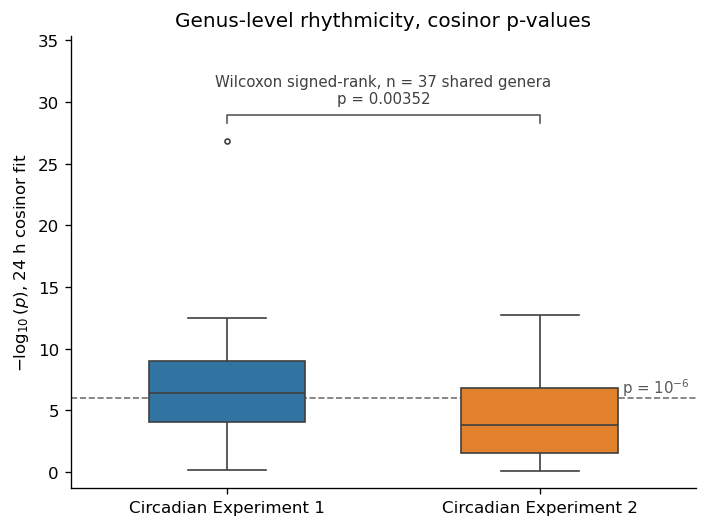

In [64]:
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=120)
fig.patch.set_facecolor("white")
ax.axhline(threshold_line, color="0.45", linestyle="--", linewidth=1, zorder=1)
sns.boxplot(
    data=swarm_p_values,
    x="dataset",
    y="neg_log10_p",
    hue="dataset",
    order=dataset_order,
    palette=dataset_colors,
    width=0.5,
    fliersize=3,
    linewidth=1,
    legend=False,
    zorder=2,
    ax=ax,
)

ax.text(
    1.48,
    threshold_line,
    "p = $10^{-6}$",
    color="0.35",
    fontsize=9,
    ha="right",
    va="bottom",
)

annotate_group_difference(ax)

ax.set_xlabel("")
ax.set_ylabel("$-\\log_{10}(p)$, 24 h cosinor fit")
ax.set_title("Genus-level rhythmicity, cosinor p-values")
sns.despine()
plt.tight_layout()
plt.show()

In [65]:
threshold_counts

,dataset,p_threshold,significant_count,total_genera,significant_fraction
0,Circadian Experiment 1,1.457015e-27,0,41,0.00000
1,Circadian Experiment 1,1.984753e-27,1,41,0.02439
2,Circadian Experiment 1,2.703640e-27,1,41,0.02439
3,Circadian Experiment 1,3.682912e-27,1,41,0.02439
4,Circadian Experiment 1,5.016882e-27,1,41,0.02439
...,...,...,...,...,...
395,Circadian Experiment 2,2.191510e-01,39,41,0.95122
396,Circadian Experiment 2,2.985286e-01,39,41,0.95122
397,Circadian Experiment 2,4.066572e-01,39,41,0.95122
398,Circadian Experiment 2,5.539504e-01,40,41,0.97561


In [66]:
cosinor_results_2.to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/Circadian_experiment_2_microbiome_cosinor_results.csv",
    index=False,
)

In [67]:
cosinor_results

,test,period,p,q,amplitude,p(amplitude),q(amplitude),CI(amplitude),acrophase,p(acrophase),q(acrophase),CI(acrophase),acrophase[h]
0,Actinomycetospora,24.0,5.379308e-12,2.756895e-11,0.383651,3.047744e-16,1.561969e-15,"[np.float64(0.291630396333432), np.float64(0.4...",-1.081838,6.856343e-18,2.162385e-17,"[np.float64(-1.327897921329411), np.float64(-0...",4.132318
1,Actinoplanes,24.0,1.515468e-05,2.301267e-05,0.600663,6.900296e-07,1.047823e-06,"[np.float64(0.36350704159520214), np.float64(0...",-0.942379,6.815204e-06,9.314113e-06,"[np.float64(-1.3528863034304124), np.float64(-...",3.599622
2,Aeromicrobium,24.0,7.891305e-08,2.022147e-07,0.291472,6.318759e-10,1.619182e-09,"[np.float64(0.19906633097834242), np.float64(0...",-1.050365,2.800384e-10,5.218897e-10,"[np.float64(-1.3766504583049197), np.float64(-...",4.012100
3,Aetherobacter,24.0,5.978572e-09,1.885550e-08,0.345548,1.616941e-11,5.099582e-11,"[np.float64(0.24501946864477123), np.float64(0...",-1.109849,2.667294e-13,5.755740e-13,"[np.float64(-1.4074145149139605), np.float64(-...",4.239312
4,Agrobacterium,24.0,1.128190e-12,9.251161e-12,0.871859,2.181700e-17,1.788994e-16,"[np.float64(0.6704358865537218), np.float64(1....",-0.984750,7.278634e-16,1.865150e-15,"[np.float64(-1.2240430416224108), np.float64(-...",3.761469
5,Aureimonas_A_501549,24.0,7.760615e-06,1.223789e-05,0.195302,2.911548e-07,4.591287e-07,"[np.float64(0.12067146970843007), np.float64(0...",-1.715619,4.324284e-20,2.216196e-19,"[np.float64(-2.0819228279376887), np.float64(-...",6.553180
6,Blastococcus,24.0,9.247049e-13,9.251161e-12,0.399117,1.590179e-17,1.629934e-16,"[np.float64(0.3073072149039414), np.float64(0....",-1.086556,1.733470e-19,7.110048e-19,"[np.float64(-1.3224212990092707), np.float64(-...",4.150339
7,Brevundimonas,24.0,3.659592e-07,7.144917e-07,0.330625,4.997165e-09,9.756371e-09,"[np.float64(0.2198016341469156), np.float64(0....",-1.943269,3.057935e-33,2.507507e-32,"[np.float64(-2.260336104381141), np.float64(-1...",7.422742
8,Caldora,24.0,1.174420e-11,5.350137e-11,0.310880,1.029738e-15,4.691026e-15,"[np.float64(0.23493692534154612), np.float64(0...",-0.781499,2.514597e-09,3.965327e-09,"[np.float64(-1.0384761442245374), np.float64(-...",2.985108
9,Chryseobacterium_A_796612,24.0,6.802529e-03,7.339570e-03,0.336398,1.234972e-03,1.332470e-03,"[np.float64(0.13231437725941173), np.float64(0...",0.488410,1.055308e-01,1.109427e-01,"[np.float64(-0.10300168951299726), np.float64(...",22.134413


In [73]:
# Benjamini-Hochberg FDR correction of the cosinor p-values.
# The plots above threshold on raw p-values, which ignores that every genus was
# tested independently. Here we convert both experiments' p-values to q-values
# and then redo the same four plots on the q-values.
from statsmodels.stats.multitest import multipletests

# alpha controls the BH correction itself; plot_threshold is only the dotted
# reference line drawn on the plots below, and does not affect the q-values.
fdr_alpha = 0.05
plot_threshold = 1e-5
plot_threshold_line = -np.log10(plot_threshold)
plot_threshold_label = "q = $10^{-5}$"


def add_bh_qvalues(results, alpha=fdr_alpha):
    """Return a copy of a cosinor result table with a BH q-value column.

    Genera with a missing p-value keep a missing q-value rather than being
    dropped, so the corrected table stays aligned with the original.
    """
    corrected = results.copy()
    corrected["q"] = np.nan
    corrected["passes_fdr"] = False

    testable = corrected["p"].notna()
    if testable.any():
        rejected, qvalues, _, _ = multipletests(
            corrected.loc[testable, "p"], alpha=alpha, method="fdr_bh"
        )
        corrected.loc[testable, "q"] = qvalues
        corrected.loc[testable, "passes_fdr"] = rejected

    return corrected


cosinor_results_bh = add_bh_qvalues(cosinor_results)
cosinor_results_2_bh = add_bh_qvalues(cosinor_results_2)

for name, table in [
    ("Circadian Experiment 1", cosinor_results_bh),
    ("Circadian Experiment 2", cosinor_results_2_bh),
]:
    n_tested = table["p"].notna().sum()
    print(
        f"{name}: {table['passes_fdr'].sum()} / {n_tested} genera at BH q < "
        f"{fdr_alpha}  (raw p < {fdr_alpha}: "
        f"{(table['p'] < fdr_alpha).sum()});  "
        f"{(table['q'] < plot_threshold).sum()} below the q < {plot_threshold} "
        f"line drawn on the plots"
    )

Circadian Experiment 1: 39 / 41 genera at BH q < 0.05  (raw p < 0.05: 39);  25 below the q < 1e-05 line drawn on the plots
Circadian Experiment 2: 31 / 41 genera at BH q < 0.05  (raw p < 0.05: 34);  14 below the q < 1e-05 line drawn on the plots


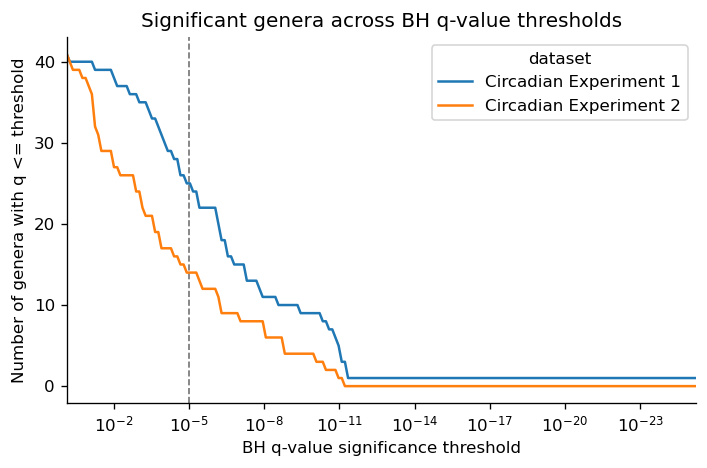

In [74]:
# Rebuild the threshold sweep on q-values instead of raw p-values.
plot_results_bh = pd.concat(
    [
        cosinor_results_bh[["q"]].assign(dataset="Circadian Experiment 1"),
        cosinor_results_2_bh[["q"]].assign(dataset="Circadian Experiment 2"),
    ],
    ignore_index=True,
)

positive_q = plot_results_bh.loc[plot_results_bh["q"] > 0, "q"]
if positive_q.empty:
    raise ValueError("No positive q-values were found to build the threshold plot.")

q_thresholds = np.logspace(
    np.log10(positive_q.min()),
    np.log10(plot_results_bh["q"].max()),
    200,
)

threshold_count_frames_bh = []
for dataset_name, dataset_df in plot_results_bh.groupby("dataset"):
    valid_q = dataset_df["q"].dropna()
    total_genera = len(valid_q)
    threshold_count_frames_bh.append(
        pd.DataFrame(
            {
                "dataset": dataset_name,
                "q_threshold": q_thresholds,
                "significant_count": [
                    (valid_q <= threshold).sum() for threshold in q_thresholds
                ],
                "total_genera": total_genera,
                "significant_fraction": [
                    (valid_q <= threshold).sum() / total_genera
                    for threshold in q_thresholds
                ],
            }
        )
    )

threshold_counts_bh = pd.concat(threshold_count_frames_bh, ignore_index=True)

# Plot 1 of 4: absolute number of genera passing each q threshold.
# The raw p-value version of this plot drew the fraction despite its axis label,
# so the count is plotted here to match the label and to complement the next plot.
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
fig.patch.set_facecolor("white")
sns.lineplot(
    data=threshold_counts_bh,
    x="q_threshold",
    y="significant_count",
    hue="dataset",
    ax=ax,
)
ax.axvline(plot_threshold, color="0.45", linestyle="--", linewidth=1, zorder=1)
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_xlim(
    max(q_thresholds.max(), plot_threshold),
    min(q_thresholds.min(), plot_threshold),
)
ax.set_xlabel("BH q-value significance threshold")
ax.set_ylabel("Number of genera with q <= threshold")
ax.set_title("Significant genera across BH q-value thresholds")
sns.despine()
plt.tight_layout()
plt.show()

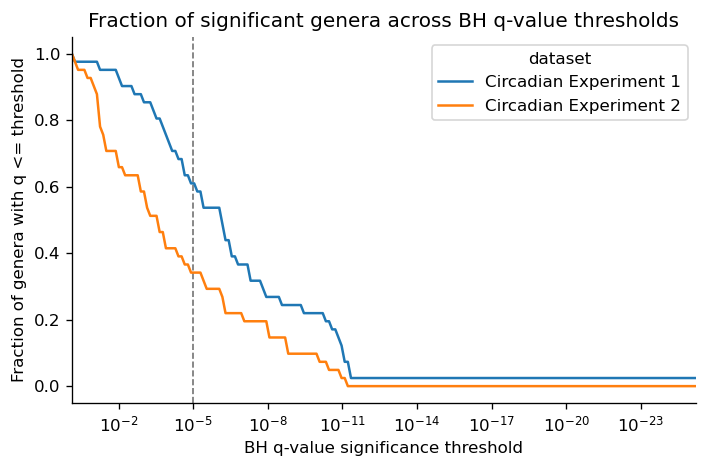

In [75]:
# Plot 2 of 4: same sweep as a fraction of the genera tested.
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
fig.patch.set_facecolor("white")
sns.lineplot(
    data=threshold_counts_bh,
    x="q_threshold",
    y="significant_fraction",
    hue="dataset",
    ax=ax,
)
ax.axvline(plot_threshold, color="0.45", linestyle="--", linewidth=1, zorder=1)
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_xlim(
    max(q_thresholds.max(), plot_threshold),
    min(q_thresholds.min(), plot_threshold),
)
ax.set_xlabel("BH q-value significance threshold")
ax.set_ylabel("Fraction of genera with q <= threshold")
ax.set_title("Fraction of significant genera across BH q-value thresholds")
sns.despine()
plt.tight_layout()
plt.show()

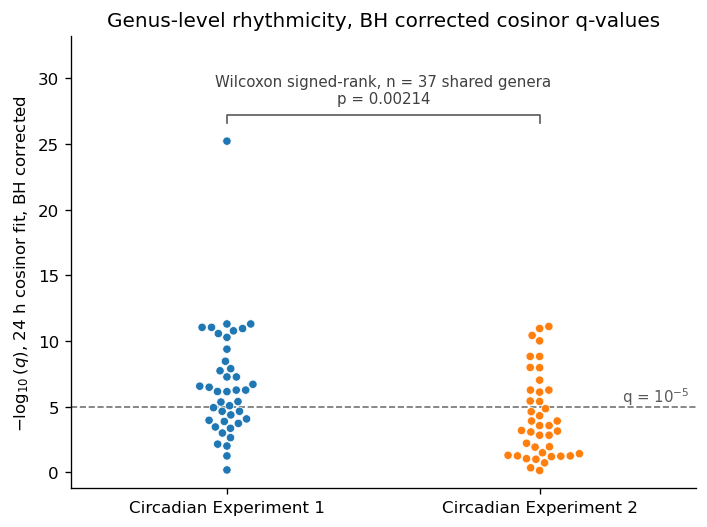

In [76]:
# Per-genus q-values for the swarm and box plots, plus the paired test between
# the two experiments recomputed on the corrected values.
swarm_q_values = pd.concat(
    [
        cosinor_results_bh[["test", "q"]].assign(dataset="Circadian Experiment 1"),
        cosinor_results_2_bh[["test", "q"]].assign(dataset="Circadian Experiment 2"),
    ],
    ignore_index=True,
)
swarm_q_values = swarm_q_values.loc[swarm_q_values["q"] > 0].copy()
swarm_q_values["neg_log10_q"] = -np.log10(swarm_q_values["q"])
swarm_q_values["passes_threshold"] = (
    swarm_q_values["neg_log10_q"] >= plot_threshold_line
)

shared_genera_bh = cosinor_results_bh[["test", "q"]].merge(
    cosinor_results_2_bh[["test", "q"]], on="test", suffixes=("_1", "_2")
)
shared_genera_bh = shared_genera_bh.loc[
    (shared_genera_bh["q_1"] > 0) & (shared_genera_bh["q_2"] > 0)
]
group_difference_bh = stats.wilcoxon(
    -np.log10(shared_genera_bh["q_1"]), -np.log10(shared_genera_bh["q_2"])
)
group_difference_label_bh = (
    f"Wilcoxon signed-rank, n = {len(shared_genera_bh)} shared genera\n"
    f"p = {group_difference_bh.pvalue:.3g}"
)


def annotate_group_difference_bh(ax):
    """Draw a significance bracket spanning the two experiment columns."""
    x_limits = ax.get_xlim()
    top_value = swarm_q_values["neg_log10_q"].max()
    bracket_y = top_value * 1.08
    tick = top_value * 0.025
    ax.plot(
        [0, 0, 1, 1],
        [bracket_y - tick, bracket_y, bracket_y, bracket_y - tick],
        color="0.35",
        linewidth=1,
        clip_on=False,
        zorder=3,
    )
    ax.text(
        0.5,
        bracket_y + tick,
        group_difference_label_bh,
        ha="center",
        va="bottom",
        fontsize=9,
        color="0.25",
    )
    ax.set_ylim(top=bracket_y * 1.22)
    ax.set_xlim(x_limits)


# Plot 3 of 4: per-genus q-values, one point per genus.
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=120)
fig.patch.set_facecolor("white")
ax.axhline(plot_threshold_line, color="0.45", linestyle="--", linewidth=1, zorder=1)
sns.swarmplot(
    data=swarm_q_values,
    x="dataset",
    y="neg_log10_q",
    hue="dataset",
    order=dataset_order,
    palette=dataset_colors,
    size=5,
    linewidth=0.4,
    edgecolor="white",
    legend=False,
    zorder=2,
    ax=ax,
)

ax.text(
    1.48,
    plot_threshold_line,
    plot_threshold_label,
    color="0.35",
    fontsize=9,
    ha="right",
    va="bottom",
)

annotate_group_difference_bh(ax)

ax.set_xlabel("")
ax.set_ylabel("$-\\log_{10}(q)$, 24 h cosinor fit, BH corrected")
ax.set_title("Genus-level rhythmicity, BH corrected cosinor q-values")
sns.despine()
plt.tight_layout()
plt.show()

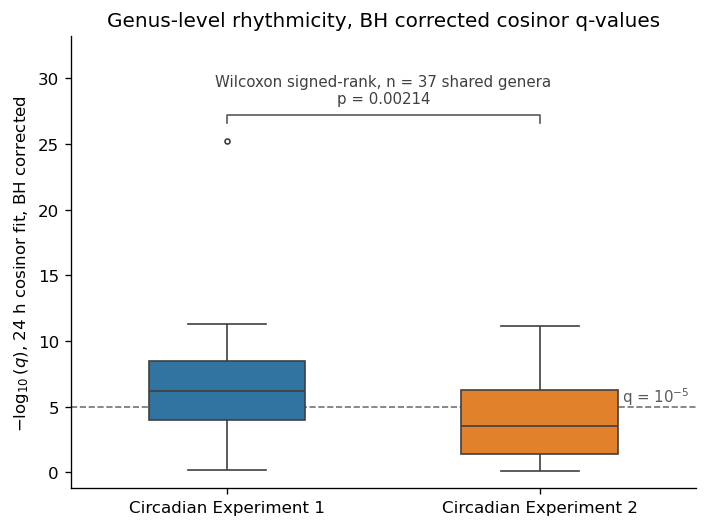

In [77]:
# Plot 4 of 4: the same q-value distributions summarised as boxes.
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=120)
fig.patch.set_facecolor("white")
ax.axhline(plot_threshold_line, color="0.45", linestyle="--", linewidth=1, zorder=1)
sns.boxplot(
    data=swarm_q_values,
    x="dataset",
    y="neg_log10_q",
    hue="dataset",
    order=dataset_order,
    palette=dataset_colors,
    width=0.5,
    fliersize=3,
    linewidth=1,
    legend=False,
    zorder=2,
    ax=ax,
)

ax.text(
    1.48,
    plot_threshold_line,
    plot_threshold_label,
    color="0.35",
    fontsize=9,
    ha="right",
    va="bottom",
)

annotate_group_difference_bh(ax)

ax.set_xlabel("")
ax.set_ylabel("$-\\log_{10}(q)$, 24 h cosinor fit, BH corrected")
ax.set_title("Genus-level rhythmicity, BH corrected cosinor q-values")
sns.despine()
plt.tight_layout()
plt.show()